# Panels 4K, 4I, 4N (Session Pair Example)

Split from `ahmm_final_figures.ipynb`. Covers the paired-session example used for posterior tuning, first-bar tuning, and neural-to-model similarity matrix. The original notebook labels one subsection as 4I; that label is preserved in the copied cells.


In [7]:
import pickle
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ahmm_eval import (
    build_cat_ids_from_obs_labels,
    build_conditioned_obs_heatmap,
    build_similarity_matrix,
    build_within_session_pv_cov_df_best_models,
    collect_left_tuning_all_sessions_from_df,
    collect_pv_lag_curves_for_best_models,
    compute_state_tuning_all_obs,
    load_best_pde_model_for_session,
    load_within_session_model_for_session,
    model_action_distribution_all_sessions,
    obs_heatmap_corr_for_session_and_model,
    prepare_obs_heatmap_crosscorr_2x2,
    sample_ahmm,
    save_pv_df_to_mat,
    select_left_bar_tuning,
    prep_dfv_for_heatmap,
        repair_model_paths,
    resolve_data_path,
)
from ahmm_plotting import (
    build_obs_raster_sorted,
    make_obs_colors,
    parula,
    plot_conditioned_obs_heatmap,
    plot_confusion_heatmap,
    plot_heatmap_and_pc_loadings,
    plot_metric_heatmap,
    plot_model_action_heatmap,
    plot_obj1_tuning_heatmap,
    plot_obs_raster_sorted,
    plot_pv_df_violin_sanity,
    plot_pv_lag_mean_sem,
    plot_tuning_heatmap,
    show_pv_representation_ahmm_dataset,
)
from ahmm_utils import (
    SingleTrackConfig,
    SingleTrackGenerator,
    Vocab,
    build_vocab,
    load_ahmm,
    make_session_lookup,
    records_to_dataset,
    train_test_split_random,
)




In [8]:
sessions_combined = pd.read_pickle(resolve_data_path('sessions_combined.pkl', data_roots=('data','demo_data','.')))



In [9]:
heights_in_data = sorted({
    int(h) for sess in sessions_combined for (h, _, _) in sess["records"]
} | {
    int(h) for sess in sessions_combined for (_, h, _) in sess["records"]
})
heights = heights_in_data  # or overwrite with your canonical list if you prefer

vocab: Vocab = build_vocab(heights, height_encoding='split')

# Your deterministic task config (you can change these to experiment)
cfg = SingleTrackConfig(
    tower_heights=heights,
    height_encoding='split',
    p_gap=1.0,
    p_reward_given_correct=1.0,
    p_reward_given_incorrect=0.0
)
gen = SingleTrackGenerator(vocab, cfg)

action_labels = [vocab.id_to_action[i] for i in range(len(vocab.id_to_action))]
obs_labels    = [k for k,_ in sorted(vocab.obs_to_id.items(), key=lambda kv: kv[1])]
obs_colors    = make_obs_colors(obs_labels)
sess_by_key = make_session_lookup(sessions_combined)




In [10]:
dfv_rand_25 = repair_model_paths(pd.read_pickle(resolve_data_path("dfv_rand_25.pkl", data_roots=("data","demo_data","."))))



In [11]:
df_25_rand = repair_model_paths(pd.read_pickle(resolve_data_path("df_25_rand.pkl", data_roots=("data","demo_data","."))))



In [12]:
cg_df_rand_25 = repair_model_paths(pd.read_pickle(resolve_data_path("rand_train_val_cg_rank1_pde_behavior_cross_compare_results_25_states.pkl", data_roots=("data","demo_data","."))))



### Figure 4K

In [13]:
# animal_s3 = "G375"
# date_s3   = "2023-03-03"

animal_s3 = "G386"
date_s3   = "2023-11-22"

sess_s3 = sess_by_key.get((animal_s3, date_s3), None)
if sess_s3 is None:
    raise ValueError(f"No session found for {animal_s3} {date_s3}")
ds_session_s3 = records_to_dataset(sess_s3["records"], gen)

# animal_s4 = "G506"
# date_s4 = "2025-11-06"

animal_s4 = "G375"
date_s4 = "2023-03-09"

sess_s4 = sess_by_key.get((animal_s4, date_s4), None)
if sess_s4 is None:
    raise ValueError(f"No session found for {animal_s4} {date_s4}")
ds_session_s4 = records_to_dataset(sess_s4["records"], gen)



In [14]:
model_s3, _, row_v_s3, row_model_s3 = load_within_session_model_for_session(
    dfv_rand_25,
    df_25_rand,
    animal_s3,
    date_s3,
    load_fn=load_ahmm
)
tuning_all_s3, counts_all_s3, obs_labels = compute_state_tuning_all_obs(model_s3, ds_session_s3, vocab)



In [15]:
model_s4, _, row_v_s4, row_model_s4 = load_within_session_model_for_session(
    dfv_rand_25,
    df_25_rand,
    animal_s4,
    date_s4,
    load_fn=load_ahmm
)

tuning_all_s4, counts_all_s4, obs_labels = compute_state_tuning_all_obs(model_s4, ds_session_s4, vocab)



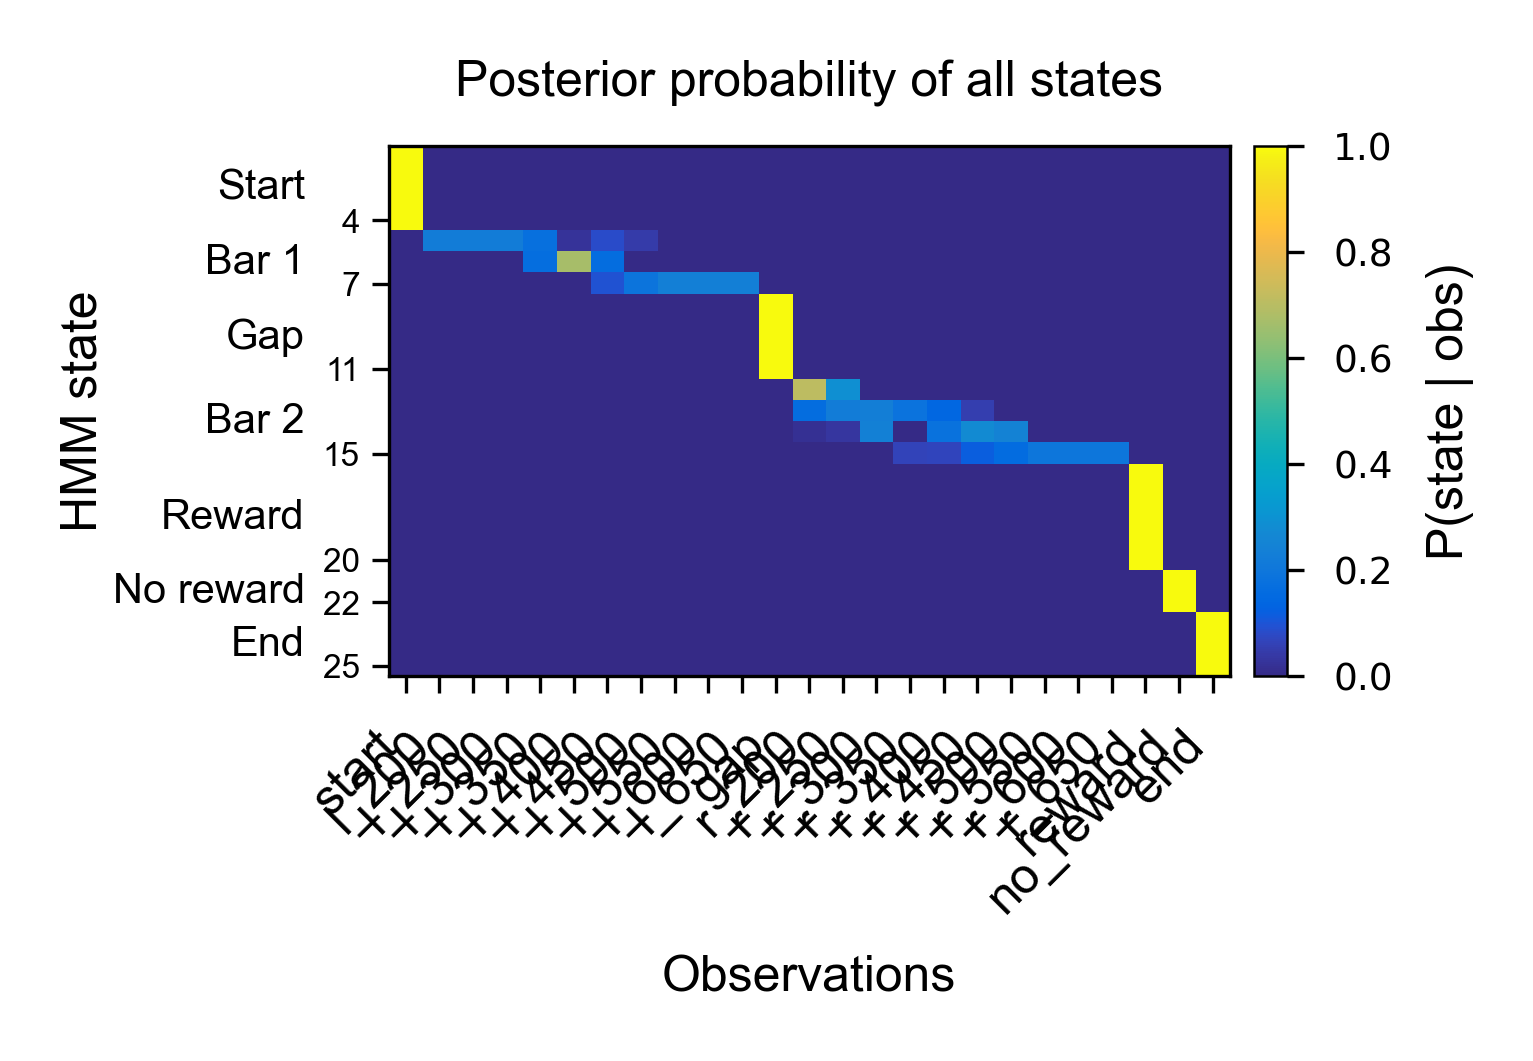

In [16]:
cat_ids, _, id_to_name = build_cat_ids_from_obs_labels(tuning_all_s3, obs_labels)

fig, ax, state_ordered, cat_ids_sorted = plot_tuning_heatmap(
    tuning_all_s3,
    obs_labels,
    normalize="sum",
    cmap=parula,
    cat_ids=cat_ids,
    id_to_name=id_to_name,
    enable_cat_blocks=True,
    sort="peak",
    figsize_cm=(6, 4),
    dpi=600,
    title="Posterior probability of all states",
    fontsize=dict(
        title=6,
        axis_label=6,
        tick=6,
        cbar_label=6,
        cbar_tick=4.5,
        cat_label=5,
        cat_count=4,
    ),
    draw_cat_separators=False,
    cbar_size=0.04,
    cbar_pad=0.04,
    cat_label_x=-3,
    cbar_outline_width=0.3,
    ylabel_pad=26,
    cat_counts_pad=1.5,

)





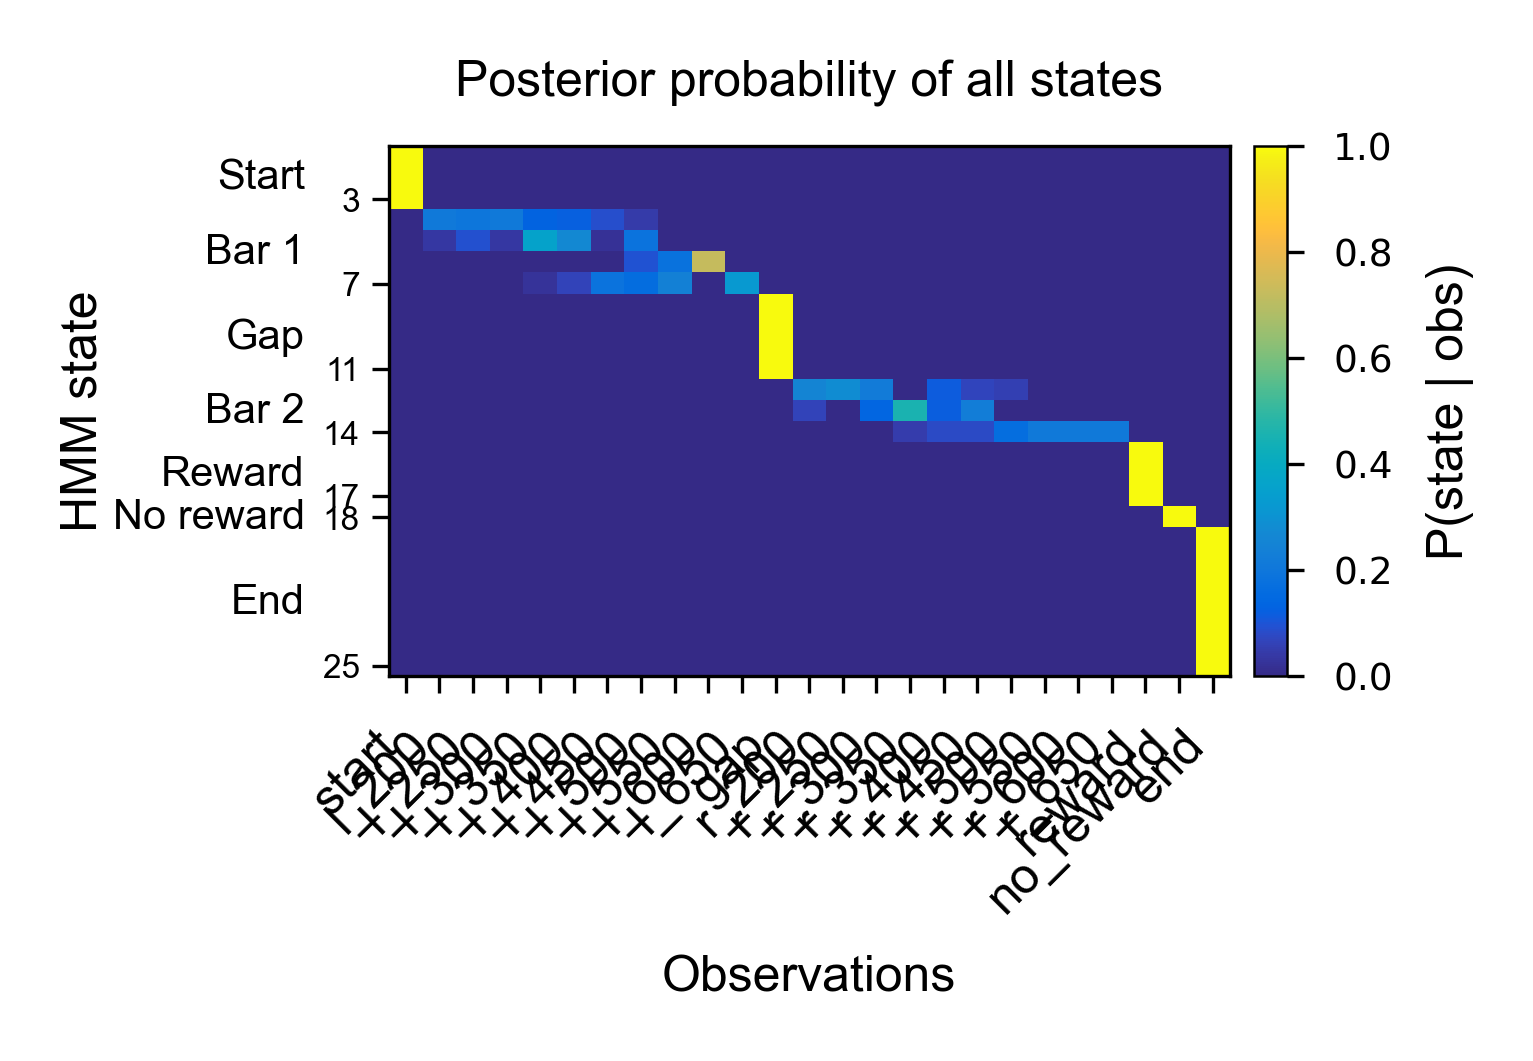

In [17]:
cat_ids, _, id_to_name = build_cat_ids_from_obs_labels(tuning_all_s4, obs_labels)

fig, ax, state_ordered_s4, cb = plot_tuning_heatmap(
    tuning_all_s4,
    obs_labels,
    normalize="sum",
    cmap=parula,
    cat_ids=cat_ids,
    id_to_name=id_to_name,
    enable_cat_blocks=True,
    sort="peak",
    figsize_cm=(6, 4),
    dpi=600,
    title="Posterior probability of all states",
    fontsize=dict(
        title=6,
        axis_label=6,
        tick=6,
        cbar_label=6,
        cbar_tick=4.5,
        cat_label=5,
        cat_count=4,
    ),
    draw_cat_separators=False,
    cbar_size=0.04,
    cbar_pad=0.04,
    cat_label_x=-3,
    cbar_outline_width=0.3,
    ylabel_pad=26,
    cat_counts_pad=1.5,

)





### Figure 4I

In [19]:
df_trials_all_s3 = pd.read_pickle(resolve_data_path(f'{animal_s3}_all_session_processed_data.pkl', data_roots=('data','demo_data','.')))
df_trials_all_s4 = pd.read_pickle(resolve_data_path(f'{animal_s4}_all_session_processed_data.pkl', data_roots=('data','demo_data','.')))



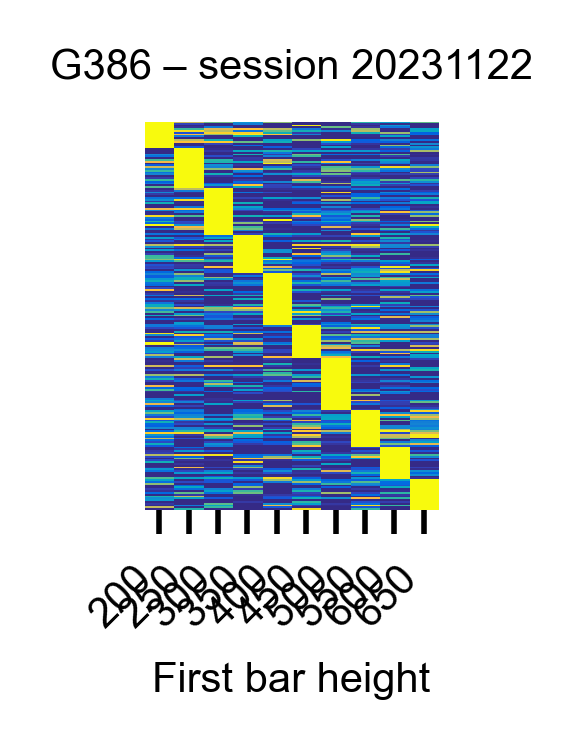

In [20]:
fig, ax, out = plot_obj1_tuning_heatmap(
    df_trials_all_s3,
    date_s3,
    cmap=parula,
    normalize="minmax",
    sort_by="pref",
    figsize=(1, 1.6),
    dpi=500,
    fontname="Arial",
    title=f"{animal_s3} – session {pd.to_datetime(date_s3).strftime('%Y%m%d')}",
    fontsize=dict(
        title=6,
        axis_label=6,
        xtick=6
    ),
    xlabel="First bar height",
)





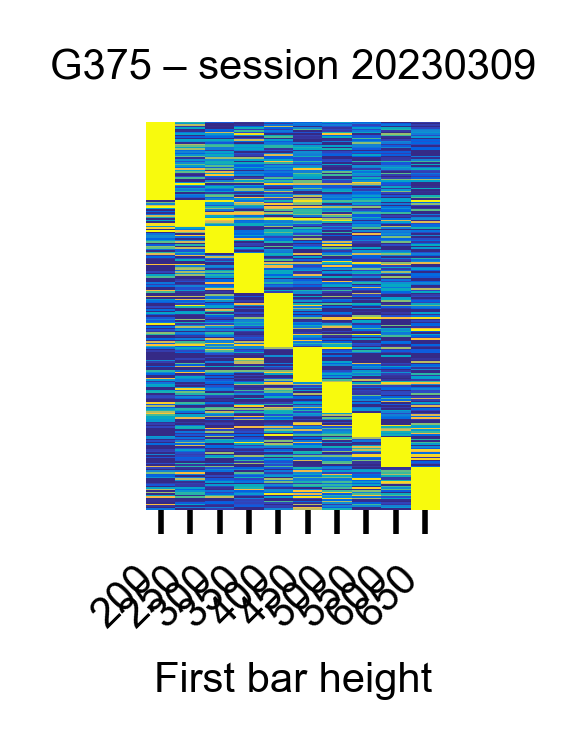

In [21]:
fig, ax, out = plot_obj1_tuning_heatmap(
    df_trials_all_s4,
    date_s4,
    cmap=parula,
    normalize="minmax",
    sort_by="pref",
    figsize=(1, 1.6),
    dpi=500,
    fontname="Arial",
    title=f"{animal_s4} – session {pd.to_datetime(date_s4).strftime('%Y%m%d')}",
    fontsize=dict(
        title=6,
        axis_label=6,
        xtick=6
    ),
    xlabel="First bar height",
)





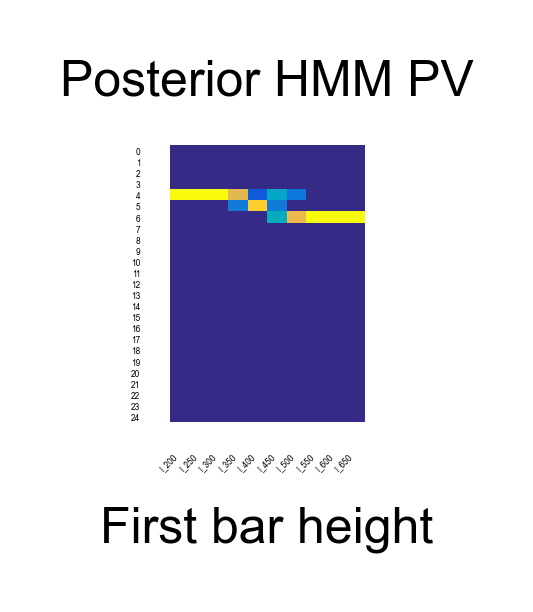

In [22]:
tuning_left_s3, obs_left = select_left_bar_tuning(tuning_all_s3, obs_labels)
tuning_left_s3 = tuning_left_s3[state_ordered]

fig, ax, state_ordered, cb  = plot_tuning_heatmap(
    tuning_left_s3,
    obs_left,
    # normalize="sum",     # or None / "sum" / "zscore"
    sort="none",
    cmap=parula,
    figsize_cm=(1, 2.1),
    dpi=600,
    title="Posterior HMM PV",
    fontsize=dict(
        title=6,
        axis_label=6,
        tick=0,
        cbar_label=0,
        cbar_tick=0,
        cat_label=5,
        cat_count=4,
    ),
    xlabel="First bar height",
    ylabel="",
    draw_cat_separators=False,
    cbar_size=0,
    cbar_pad=0,
    cat_label_x=0,
    cbar_outline_width=0.3,
    ylabel_pad=0,
    cat_counts_pad=0,
    show_cbar=False,
    show_spines=False,
    tick_length=0
)




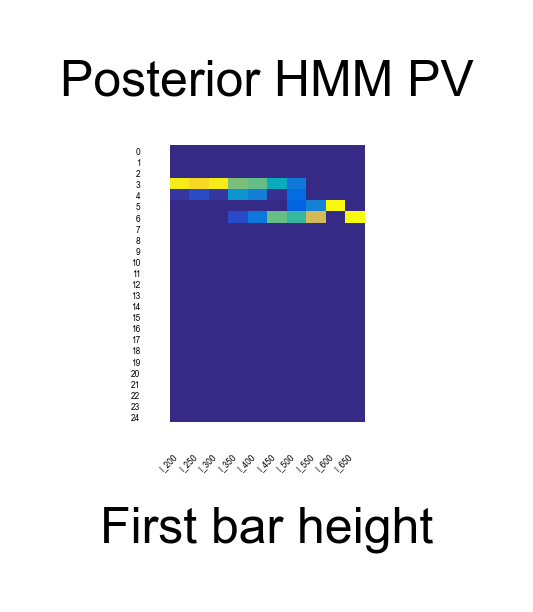

In [23]:
tuning_left_s4, obs_left = select_left_bar_tuning(tuning_all_s4, obs_labels)
tuning_left_s4 = tuning_left_s4[state_ordered_s4]

fig, ax, state_ordered, cb  = plot_tuning_heatmap(
    tuning_left_s4,
    obs_left,
    # normalize="sum",     # or None / "sum" / "zscore"
    sort="none",
    cmap=parula,
    figsize_cm=(1, 2.1),
    dpi=600,
    title="Posterior HMM PV",
    fontsize=dict(
        title=6,
        axis_label=6,
        tick=0,
        cbar_label=0,
        cbar_tick=0,
        cat_label=5,
        cat_count=4,
    ),
    xlabel="First bar height",
    ylabel="",
    draw_cat_separators=False,
    cbar_size=0,
    cbar_pad=0,
    cat_label_x=0,
    cbar_outline_width=0.3,
    ylabel_pad=0,
    cat_counts_pad=0,
    show_cbar=False,
    show_spines=False,
    tick_length=0
)




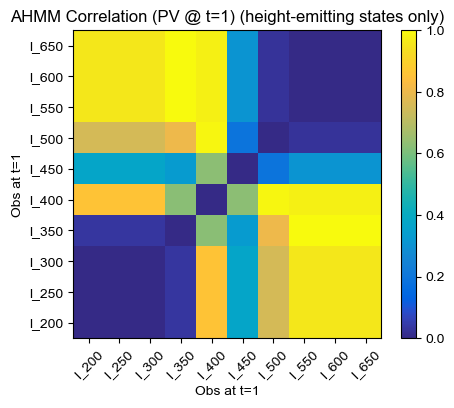

In [24]:
M, matrix_rep_s3, gammas_rep = show_pv_representation_ahmm_dataset(
    t=1, s=1, dataset=ds_session_s3, model=model_s3,
    tower_heights=heights, id_to_obs=vocab.id_to_obs, metric="corr"
)




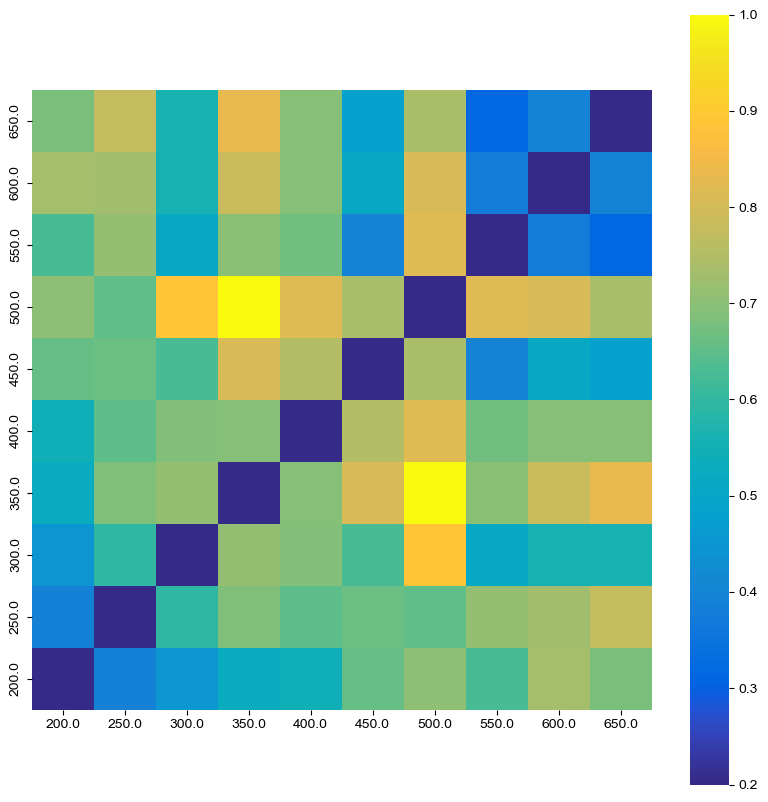

In [30]:
with open(resolve_data_path(f"{animal_s3}_all_sessions_neural_pv_representation.pkl", data_roots=("data","demo_data",".")), "rb") as f:
    dist_matrices = pickle.load(f)
neural_matrix_s3 = dist_matrices[datetime.strptime(date_s3, "%Y-%m-%d").strftime("%Y%m%d")
]
heights = np.linspace(200, 650, 10)
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
sns.heatmap(neural_matrix_s3, cmap=parula, vmin=0.2, vmax=1, xticklabels=heights, yticklabels=heights)
axs.invert_yaxis()
axs.set_aspect('equal')




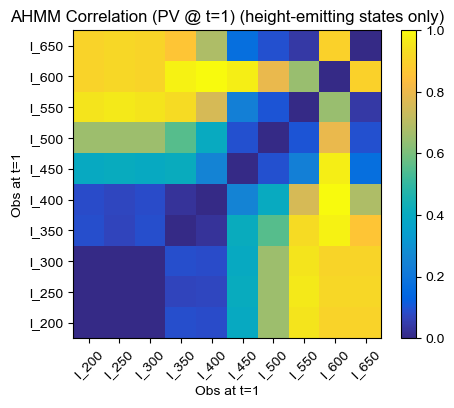

In [31]:
_, matrix_rep_s4, gammas_rep = show_pv_representation_ahmm_dataset(
    t=1, s=1, dataset=ds_session_s4, model=model_s4,
    tower_heights=heights, id_to_obs=vocab.id_to_obs, metric="corr"
)




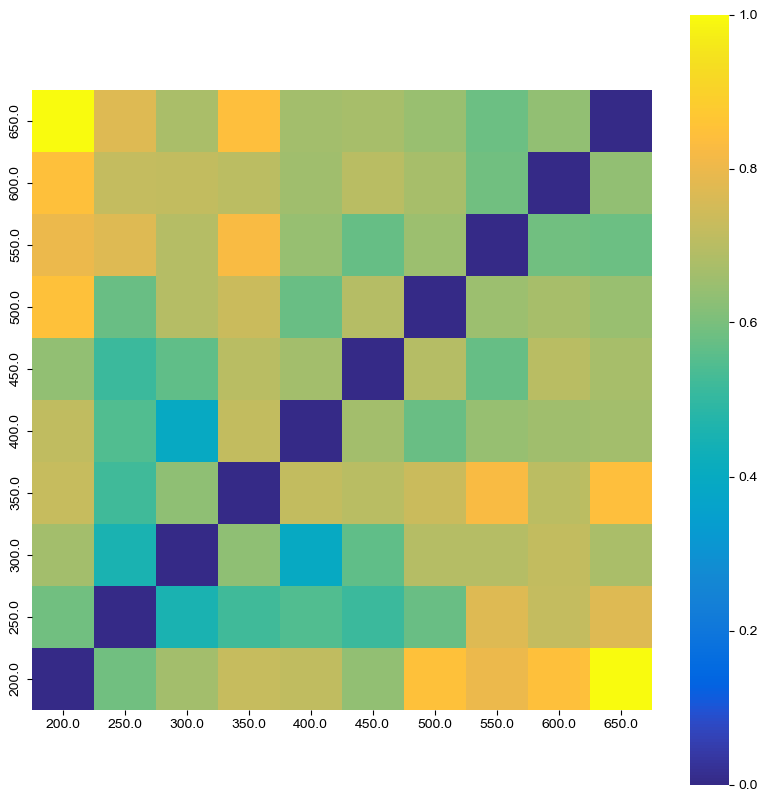

In [32]:
with open(resolve_data_path(f"{animal_s4}_all_sessions_neural_pv_representation.pkl", data_roots=("data","demo_data",".")), "rb") as f:
    dist_matrices = pickle.load(f)
neural_matrix_s4 = dist_matrices[datetime.strptime(date_s4, "%Y-%m-%d").strftime("%Y%m%d")
]
heights = np.linspace(200, 650, 10)
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
sns.heatmap(neural_matrix_s4, cmap=parula, vmin=0, vmax=1, xticklabels=heights, yticklabels=heights)
axs.invert_yaxis()
axs.set_aspect('equal')




### Figure 4N

In [33]:
sim_mat = build_similarity_matrix(
    neural_matrix_s3, matrix_rep_s3, neural_matrix_s4, matrix_rep_s4
)

print(sim_mat)




          S01       S02
S01  0.403006  0.187872
S02  0.437022  0.551360


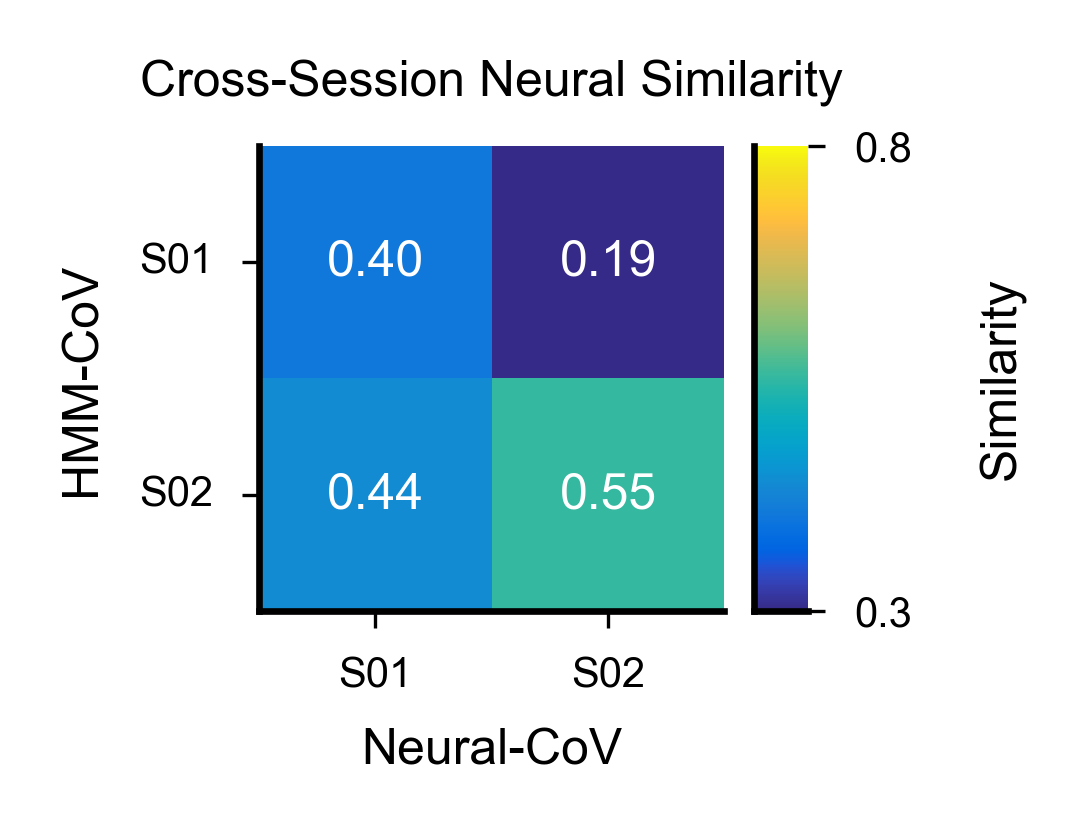

In [34]:
fig, ax = plot_confusion_heatmap(
    sim_mat,
    cmap=parula,
    figsize_cm=(3, 3),
    dpi=600,
    fontname="Arial",
    fontsize=dict(title=6, axis_label=6, tick=5, annot=6, cbar_label=6, cbar_tick=5),
    xlabel="Neural-CoV",
    ylabel="HMM-CoV",
    title="Cross-Session Neural Similarity",
    vmin=0.3,
    vmax=0.8,
    cbar_size=0.09,
    cbar_pad=0.05,
    cbar_ticks=[0.3, 0.8],
    cbar_ticklabels=["0.3", "0.8"],
    tick_width=0.4,
    tick_length=2,
)

